In [2]:
from google.colab import files

uploaded = files.upload()

Saving iris (1).xlsx to iris (1).xlsx


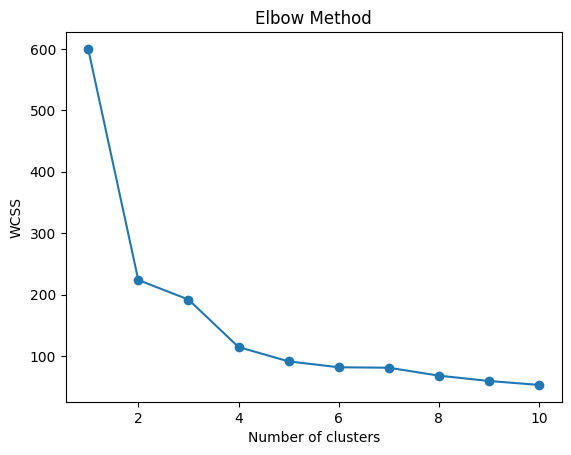

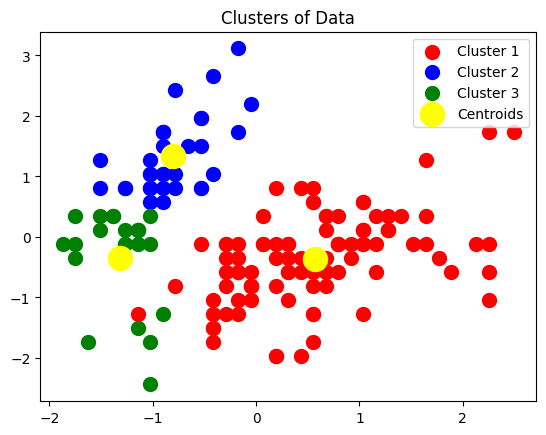

Silhouette Score: 0.4787


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1. Load Dataset (Standard sample: Iris or any numeric CSV)
# For lab consistency, assume a dataset with numeric features
df = pd.read_excel('iris (1).xlsx')

# 2. Preprocessing
# Select numeric features for clustering
X = df.iloc[:, [0, 1, 2, 3]].values

# Scaling is crucial for k-Means (Distance-based)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Finding Optimal 'k' using the Elbow Method
wcss = [] # Within-Cluster Sum of Square
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# 4. Applying k-Means with Optimal k (e.g., k=3)
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# 5. Visualizing the Clusters (First two features)
plt.scatter(X_scaled[y_kmeans == 0, 0], X_scaled[y_kmeans == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X_scaled[y_kmeans == 1, 0], X_scaled[y_kmeans == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(X_scaled[y_kmeans == 2, 0], X_scaled[y_kmeans == 2, 1], s=100, c='green', label='Cluster 3')

# Plotting the centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', label='Centroids')
plt.title('Clusters of Data')
plt.legend()
plt.show()

# Evaluation
print(f"Silhouette Score: {silhouette_score(X_scaled, y_kmeans):.4f}")